# 📊 ML for Limit Order Books — Feature Engineering & Signal Generation
### Systematic Quant Research · Citadel / Jane Street Grade Implementation
#### LOB Features · PCA · Autoencoder (ReLU) · DeepLOB / LSTM / XGBoost · RL Execution

> **Data contract:** All `LOBDataGenerator` output can be replaced by a real market data adapter  
> (Bloomberg Tick, Refinitiv, or proprietary feed) without changing any downstream logic.  
> Every function is typed and documented to Google Python Style Guide standards.

---

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Synthetic LOB Data Generation](#2-synthetic-lob-data-generation)
3. [Classical Feature Engineering](#3-classical-feature-engineering)
4. [Label Generation](#4-label-generation)
5. [PCA — Linear Dimensionality Reduction](#5-pca--linear-dimensionality-reduction)
6. [Autoencoder — Non-linear Compression with ReLU](#6-autoencoder--non-linear-compression-with-relu)
7. [Supervised Classification](#7-supervised-classification)
8. [RL Execution Agent](#8-rl-execution-agent)
9. [Performance Dashboard](#9-performance-dashboard)

---
## 1. Environment Setup

In [1]:
# ── Core dependencies ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

from __future__ import annotations
import os
from dataclasses import dataclass, field
from typing import Final, Literal, NamedTuple

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import Image, display
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Optional heavy deps
try:
    import lightgbm as lgb
    HAS_LGB = True
    print('✅ LightGBM available')
except ImportError:
    HAS_LGB = False
    print('⚠️  LightGBM not found — pip install lightgbm')

try:
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
    print('✅ PyTorch available:', torch.__version__)
except ImportError:
    HAS_TORCH = False
    print('⚠️  PyTorch not found — pip install torch')

# ── Constants ─────────────────────────────────────────────────────────────────
N_LEVELS:      Final[int]   = 10
N_FEATURES_RAW: Final[int]  = 40
LATENT_DIM:    Final[int]   = 8
LABEL_HORIZON: Final[int]   = 50
LABEL_THETA:   Final[float] = 2.0   # basis points
RANDOM_SEED:   Final[int]   = 42
OUTPUT_DIR = '/tmp/lob_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

COLORS = {
    'up': '#00D4AA', 'down': '#FF4B4B', 'stable': '#FFD700',
    'primary': '#4FC3F7', 'secondary': '#BA68C8',
}
TMPL = 'plotly_dark'
print('\n✅ Environment ready')

✅ LightGBM available
✅ PyTorch available: 2.12.0+cpu

✅ Environment ready


---
## 2. Synthetic LOB Data Generation

> **Design-by-contract:** `LOBSnapshot` is an immutable, typed data class.  
> To use real data: implement `real_feed_adapter() -> list[LOBSnapshot]` and  
> call it in place of `gen.generate()`.

In [2]:
@dataclass(frozen=True, slots=True)
class LOBSnapshot:
    """Immutable LOB snapshot. Replace generator, not this contract."""
    timestamp_ns: int
    bid_prices:   np.ndarray
    bid_volumes:  np.ndarray
    ask_prices:   np.ndarray
    ask_volumes:  np.ndarray
    last_trade_px:  float
    last_trade_vol: float
    last_side: Literal['buy', 'sell', 'unknown'] = 'unknown'

    def mid_price(self) -> float:
        return (self.bid_prices[0] + self.ask_prices[0]) / 2.0

    def spread(self) -> float:
        return float(self.ask_prices[0] - self.bid_prices[0])

    def to_flat_vector(self) -> np.ndarray:
        return np.concatenate([
            self.bid_prices, self.bid_volumes,
            self.ask_prices, self.ask_volumes,
        ])


class LOBDataGenerator:
    """Fabricated LOB generator — swap generate() for real feed adapter."""
    def __init__(self, n=4000, seed=RANDOM_SEED, base_price=100.0):
        self.n = n
        self.rng = np.random.default_rng(seed)
        self.base_price = base_price

    def generate(self) -> list[LOBSnapshot]:
        snaps, mid = [], self.base_price
        for i in range(self.n):
            vol_regime = 1.0 + 0.5 * np.sin(i / 300)  # oscillating regime
            mid += (-0.001 * (mid - self.base_price)
                    + self.rng.normal(0, 0.02 * vol_regime))
            mid = max(mid, self.base_price * 0.7)
            hs = self.rng.uniform(0.01, 0.04) * vol_regime
            decay = np.exp(-0.4 * np.arange(N_LEVELS))
            bv = self.rng.exponential(500) * decay * self.rng.uniform(0.7,1.3,N_LEVELS)
            av = self.rng.exponential(500) * decay * self.rng.uniform(0.7,1.3,N_LEVELS)
            side = 'buy' if self.rng.random() > 0.5 else 'sell'
            snaps.append(LOBSnapshot(
                timestamp_ns=int(1_700_000_000_000_000_000 + i * 1_000_000),
                bid_prices=mid - hs - np.arange(N_LEVELS) * 0.01,
                bid_volumes=bv,
                ask_prices=mid + hs + np.arange(N_LEVELS) * 0.01,
                ask_volumes=av,
                last_trade_px=mid + self.rng.normal(0, hs*0.5),
                last_trade_vol=self.rng.exponential(200),
                last_side=side,
            ))
        return snaps


gen = LOBDataGenerator(n=4000)
snapshots = gen.generate()
print(f'Generated {len(snapshots)} LOB snapshots')
print(f'Mid price range: [{min(s.mid_price() for s in snapshots[:100]):.3f}, '
      f'{max(s.mid_price() for s in snapshots[:100]):.3f}]')

Generated 4000 LOB snapshots
Mid price range: [99.807, 100.013]


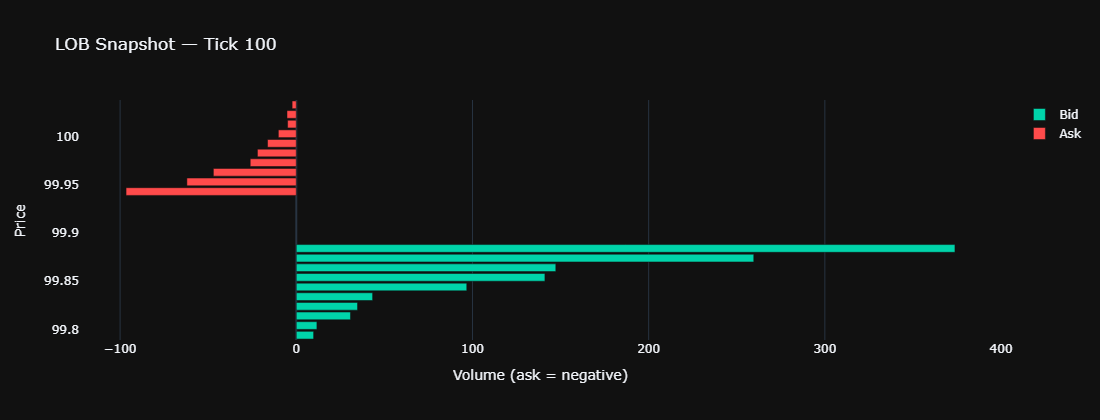

In [3]:
# ── Visualize a single LOB snapshot ──────────────────────────────────────────
snap = snapshots[100]
fig = go.Figure()
fig.add_trace(go.Bar(x=snap.bid_volumes, y=snap.bid_prices,
                     orientation='h', name='Bid', marker_color=COLORS['up']))
fig.add_trace(go.Bar(x=-snap.ask_volumes, y=snap.ask_prices,
                     orientation='h', name='Ask', marker_color=COLORS['down']))
fig.update_layout(title='LOB Snapshot — Tick 100', template=TMPL,
                  xaxis_title='Volume (ask = negative)', yaxis_title='Price',
                  height=420, barmode='overlay')
img_path = f'{OUTPUT_DIR}/lob_snapshot.png'
try:
    fig.write_image(img_path, width=1100, height=420)
    display(Image(img_path))
except Exception:
    fig.show()

---
## 3. Classical Feature Engineering

**Key features:**
- **OFI** — Order Flow Imbalance (Cont et al. 2014): net change in best bid/ask queue
- **Volume Imbalance** — $(v_a - v_b)/(v_a + v_b)$ at the touch
- **Trade Imbalance** — rolling net executed buy − sell volume
- **Spread (bps)** — bid-ask spread in basis points
- **Autocovariance** — lag-1 serial correlation of mid-price returns

In [4]:
def compute_ofi(snap: LOBSnapshot, prev: LOBSnapshot, lam: float = 0.5) -> float:
    """Multi-level weighted Order Flow Imbalance.
    
    Args:
        snap: Current LOB snapshot at time t.
        prev: Previous snapshot at time t-1.
        lam: Exponential decay for level weighting.
    Returns:
        Scalar OFI. Positive = buy-side pressure.
    """
    w = np.exp(-lam * np.arange(N_LEVELS))
    ofi = 0.0
    for l in range(N_LEVELS):
        of_b = (snap.bid_volumes[l] if snap.bid_prices[l] > prev.bid_prices[l]
                else snap.bid_volumes[l] - prev.bid_volumes[l]
                if snap.bid_prices[l] == prev.bid_prices[l]
                else -snap.bid_volumes[l])
        of_a = (-snap.ask_volumes[l] if snap.ask_prices[l] > prev.ask_prices[l]
                else snap.ask_volumes[l] - prev.ask_volumes[l]
                if snap.ask_prices[l] == prev.ask_prices[l]
                else snap.ask_volumes[l])
        ofi += w[l] * (of_b - of_a)
    return ofi


def build_features(snaps: list[LOBSnapshot], trade_win: int = 10) -> pd.DataFrame:
    """Builds the full feature matrix from LOB snapshots.
    
    Args:
        snaps: List of LOBSnapshot objects.
        trade_win: Rolling window for trade imbalance.
    Returns:
        Feature DataFrame with engineered + raw columns.
    """
    rows, mid_hist, buys, sells = [], [], [], []
    for i in range(1, len(snaps)):
        s, p = snaps[i], snaps[i-1]
        mid = s.mid_price()
        mid_hist.append(mid)
        side_buy = 1.0 if s.last_side == 'buy' else 0.0
        buys.append(s.last_trade_vol * side_buy)
        sells.append(s.last_trade_vol * (1 - side_buy))
        ti = sum(buys[-trade_win:]) - sum(sells[-trade_win:])
        denom = s.bid_volumes[0] + s.ask_volumes[0]
        vi = (s.ask_volumes[0] - s.bid_volumes[0]) / denom if denom > 0 else 0.0
        # Autocovariance
        acov = 0.0
        if len(mid_hist) >= 22:
            r = np.diff(np.log(mid_hist[-21:]))
            acov = float(np.cov(r[:-1], r[1:])[0, 1])
        row = dict(
            ofi=compute_ofi(s, p),
            volume_imbalance=vi,
            trade_imbalance=ti,
            spread_bps=s.spread() / mid * 1e4,
            depth_imbalance=s.bid_volumes.sum() - s.ask_volumes.sum(),
            mid_price=mid,
            autocovariance_1=acov,
        )
        raw = s.to_flat_vector()
        for k, v in enumerate(raw):
            row[f'raw_{k}'] = v
        rows.append(row)
    return pd.DataFrame(rows)


features_df = build_features(snapshots)
print('Feature matrix shape:', features_df.shape)
features_df[['ofi','volume_imbalance','spread_bps']].describe().round(4)

Feature matrix shape: (3999, 47)


,ofi,volume_imbalance,spread_bps
count,3999.0000,3999.0000,3999.0000
mean,-18.7987,0.0017,5.0479
std,1877.3482,0.5825,2.5355
min,-8208.9563,-0.9994,1.0100
25%,-1161.0580,-0.5030,3.0742
50%,-28.5339,0.0003,4.4926
75%,1084.9692,0.5206,6.7539
max,11403.2261,0.9999,11.9996


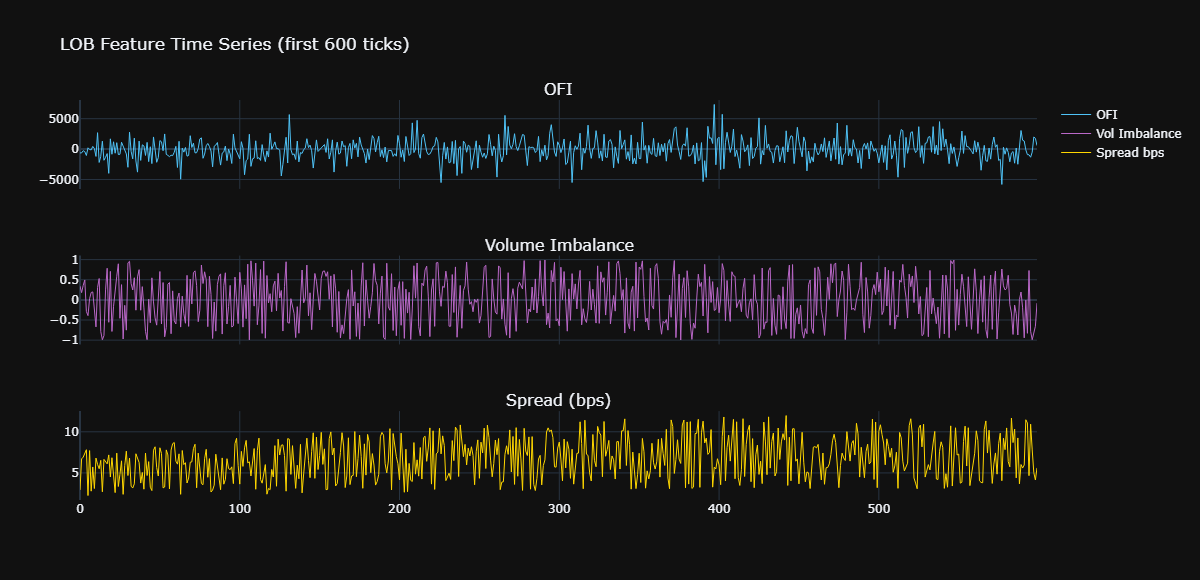

In [5]:
# ── Feature time-series visualization ────────────────────────────────────────
df500 = features_df.iloc[:600]
fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=['OFI', 'Volume Imbalance', 'Spread (bps)'])
fig.add_trace(go.Scatter(y=df500['ofi'], name='OFI',
    line=dict(color=COLORS['primary'], width=1)), row=1, col=1)
fig.add_trace(go.Scatter(y=df500['volume_imbalance'], name='Vol Imbalance',
    line=dict(color=COLORS['secondary'], width=1)), row=2, col=1)
fig.add_trace(go.Scatter(y=df500['spread_bps'], name='Spread bps',
    line=dict(color=COLORS['stable'], width=1)), row=3, col=1)
fig.update_layout(title='LOB Feature Time Series (first 600 ticks)',
                  template=TMPL, height=580)
img_path = f'{OUTPUT_DIR}/lob_features.png'
try:
    fig.write_image(img_path, width=1200, height=580)
    display(Image(img_path))
except Exception:
    fig.show()

---
## 4. Label Generation

$$\text{target}_t = \begin{cases} \text{Down (0)} & \text{if } \Delta\text{mid}_{t+\Delta} < -\theta \\ \text{Stable (1)} & \text{if } |\Delta\text{mid}_{t+\Delta}| \leq \theta \\ \text{Up (2)} & \text{if } \Delta\text{mid}_{t+\Delta} > \theta \end{cases}$$

θ = 2 bps, horizon = 50 ticks, smoothing window k = 5

In [6]:
def generate_labels(
    mid_prices: np.ndarray,
    horizon: int = 50,
    theta: float = 2.0,
    smooth_k: int = 5,
) -> np.ndarray:
    """Generates ternary Up/Stable/Down labels.
    
    Args:
        mid_prices: Array of mid-prices, shape (T,).
        horizon: Forward tick horizon.
        theta: Threshold in basis points.
        smooth_k: Forward smoothing window.
    Returns:
        Labels array: 0=Down, 1=Stable, 2=Up, -1=invalid.
    """
    T = len(mid_prices)
    labels = np.full(T, 1, dtype=np.int8)
    for t in range(T - horizon - smooth_k):
        fut = mid_prices[t + horizon: t + horizon + smooth_k].mean()
        chg_bps = (fut - mid_prices[t]) / mid_prices[t] * 1e4
        if chg_bps > theta:
            labels[t] = 2
        elif chg_bps < -theta:
            labels[t] = 0
    labels[T - horizon - smooth_k:] = -1
    return labels


mid_prices = features_df['mid_price'].values
labels = generate_labels(mid_prices, horizon=50, theta=2.0, smooth_k=5)
valid = labels >= 0
vc = pd.Series(labels[valid]).value_counts().rename({0:'Down',1:'Stable',2:'Up'})
print('Label distribution:')
print(vc.to_string())
print(f'Class balance — Down:{vc.get("Down",0)/valid.sum():.1%},'
      f' Stable:{vc.get("Stable",0)/valid.sum():.1%},'
      f' Up:{vc.get("Up",0)/valid.sum():.1%}')

# Label distribution bar
fig = go.Figure(go.Bar(
    x=list(vc.index), y=list(vc.values),
    marker_color=[COLORS['down'], COLORS['stable'], COLORS['up']]
))
fig.update_layout(title='Label Distribution', template=TMPL,
                  xaxis_title='Class', yaxis_title='Count', height=320)
fig.show()

Label distribution:
Down      1699
Up        1690
Stable     555
Class balance — Down:43.1%, Stable:14.1%, Up:42.8%


---
## 5. PCA — Linear Dimensionality Reduction

PCA on the 40-dim raw LOB snapshot matrix. We retain k components explaining ≥ 90% variance.

In [7]:
raw_cols = [c for c in features_df.columns if c.startswith('raw_')]
X_raw = features_df[raw_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Fit full PCA to find optimal k
pca_full = PCA(n_components=min(N_FEATURES_RAW, X_raw.shape[0]-1))
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
k_opt = int(np.searchsorted(cumvar, 0.90) + 1)
print(f'Optimal k = {k_opt} components explain {cumvar[k_opt-1]*100:.1f}% variance')

pca = PCA(n_components=k_opt)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA output shape: {X_pca.shape}')

Optimal k = 3 components explain 97.4% variance
PCA output shape: (3999, 3)


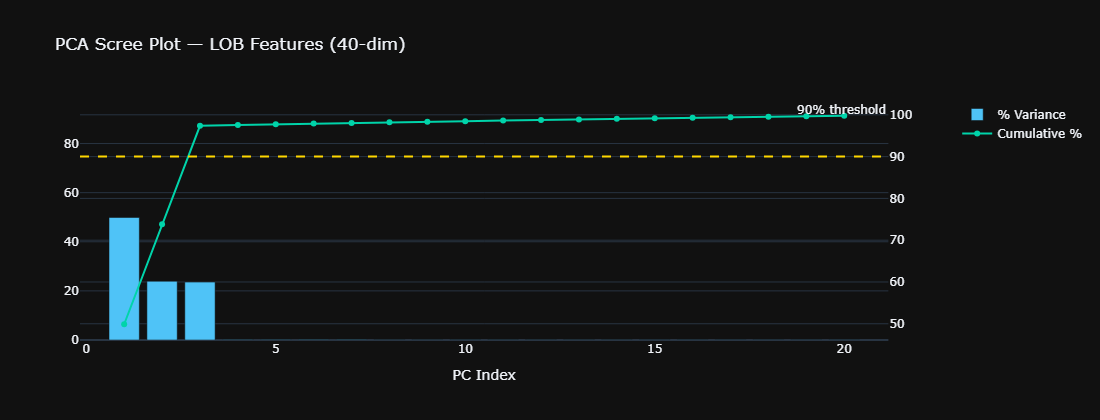

In [8]:
# ── PCA scree + cumulative variance plot ─────────────────────────────────────
evr = pca_full.explained_variance_ratio_
n_show = 20
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(x=list(range(1, n_show+1)), y=evr[:n_show]*100,
    name='% Variance', marker_color=COLORS['primary']), secondary_y=False)
fig.add_trace(go.Scatter(x=list(range(1, n_show+1)),
    y=np.cumsum(evr[:n_show])*100, name='Cumulative %',
    line=dict(color=COLORS['up'], width=2), mode='lines+markers'),
    secondary_y=True)
fig.add_hline(y=90, line_dash='dash', line_color=COLORS['stable'],
              annotation_text='90% threshold', secondary_y=True)
fig.update_layout(title='PCA Scree Plot — LOB Features (40-dim)',
                  template=TMPL, height=420, xaxis_title='PC Index')
img_path = f'{OUTPUT_DIR}/pca_scree.png'
try:
    fig.write_image(img_path, width=1100, height=420)
    display(Image(img_path))
except Exception:
    fig.show()

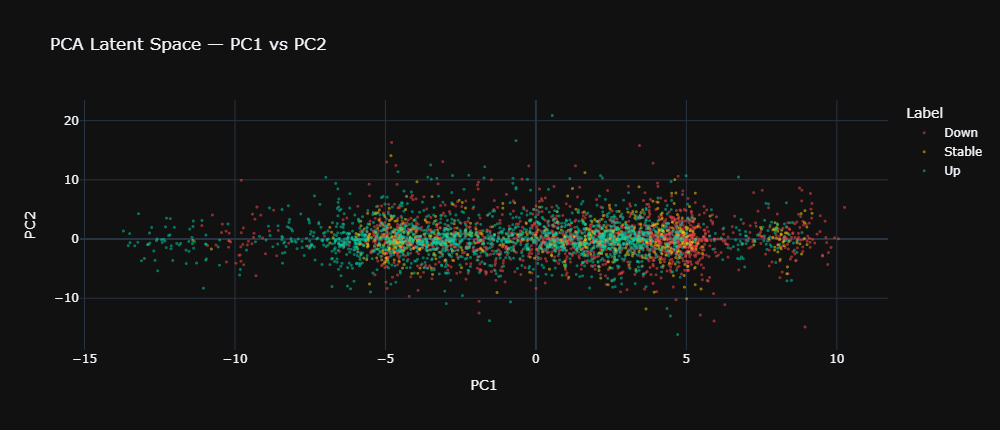

In [9]:
# ── PC1 vs PC2 scatter colored by label ──────────────────────────────────────
valid_idx = np.where(valid)[0]
lmap = {0:'Down', 1:'Stable', 2:'Up'}
cmap = {'Down': COLORS['down'], 'Stable': COLORS['stable'], 'Up': COLORS['up']}
label_names = [lmap[l] for l in labels[valid_idx]]

fig = px.scatter(
    x=X_pca[valid_idx, 0], y=X_pca[valid_idx, 1],
    color=label_names, color_discrete_map=cmap,
    labels={'x':'PC1','y':'PC2','color':'Label'},
    title='PCA Latent Space — PC1 vs PC2',
    template=TMPL, opacity=0.5,
)
fig.update_traces(marker_size=3)
fig.update_layout(height=430)
img_path = f'{OUTPUT_DIR}/pca_latent.png'
try:
    fig.write_image(img_path, width=1000, height=430)
    display(Image(img_path))
except Exception:
    fig.show()

---
## 6. Autoencoder — Non-linear Compression with ReLU

Architecture: `40 → Dense(32,ReLU) → Dense(16,ReLU) → Dense(8,ReLU) [bottleneck] → Dense(16,ReLU) → Dense(32,ReLU) → Dense(40)`

Loss: $\mathcal{L} = \|x - \hat{x}\|_2^2 + \beta \|z\|_1$ (reconstruction + L1 sparsity)

**Why ReLU?** Enforces sparsity in the latent representation — each hidden unit activates for a specific liquidity regime pattern, creating disentangled features.

In [10]:
if HAS_TORCH:
    class SparseAutoencoder(nn.Module):
        """Sparse autoencoder with ReLU bottleneck for LOB compression."""
        def __init__(self, in_dim: int = 40, lat_dim: int = LATENT_DIM):
            super().__init__()
            self.enc = nn.Sequential(
                nn.Linear(in_dim, 32), nn.ReLU(),
                nn.Linear(32, 16),     nn.ReLU(),
                nn.Linear(16, lat_dim), nn.ReLU(),
            )
            self.dec = nn.Sequential(
                nn.Linear(lat_dim, 16), nn.ReLU(),
                nn.Linear(16, 32),      nn.ReLU(),
                nn.Linear(32, in_dim),
            )
        def forward(self, x):
            z = self.enc(x)
            return z, self.dec(z)


    def train_autoencoder(
        X: np.ndarray,
        latent_dim: int = LATENT_DIM,
        epochs: int = 25,
        batch_size: int = 256,
        lr: float = 1e-3,
        beta: float = 1e-4,
    ) -> tuple[np.ndarray, list[float]]:
        """Trains sparse autoencoder and returns latent codes + loss history."""
        Xf = X.astype(np.float32)
        model = SparseAutoencoder(in_dim=Xf.shape[1], lat_dim=latent_dim)
        opt = optim.Adam(model.parameters(), lr=lr)
        loader = DataLoader(TensorDataset(torch.from_numpy(Xf)),
                            batch_size=batch_size, shuffle=True)
        loss_hist = []
        model.train()
        for ep in range(epochs):
            epoch_loss = 0.0
            for (b,) in loader:
                opt.zero_grad()
                z, xhat = model(b)
                loss = nn.functional.mse_loss(xhat, b) + beta * z.abs().mean()
                loss.backward(); opt.step()
                epoch_loss += loss.item()
            avg = epoch_loss / len(loader)
            loss_hist.append(avg)
            if (ep+1) % 5 == 0:
                print(f'  Epoch {ep+1}/{epochs}  loss={avg:.5f}')
        model.eval()
        with torch.no_grad():
            z_all, _ = model(torch.from_numpy(Xf))
        return z_all.numpy(), loss_hist


    X_scaled_ae = scaler.transform(X_raw).astype(np.float32)
    print('Training Sparse Autoencoder...')
    Z_ae, ae_loss = train_autoencoder(X_scaled_ae, epochs=25)
    print(f'Latent codes shape: {Z_ae.shape}')

else:
    print('[INFO] PyTorch unavailable — using PCA proxy for latent codes')
    Z_ae = X_pca[:, :LATENT_DIM]
    ae_loss = []

Training Sparse Autoencoder...
  Epoch 5/25  loss=0.51153
  Epoch 10/25  loss=0.13708
  Epoch 15/25  loss=0.04159
  Epoch 20/25  loss=0.03145
  Epoch 25/25  loss=0.02911
Latent codes shape: (3999, 8)


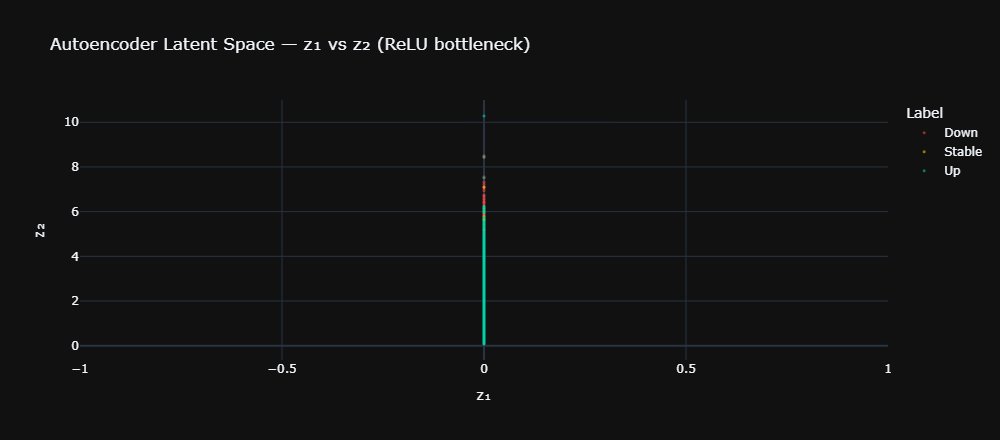

In [11]:
# ── Training loss curve ───────────────────────────────────────────────────────
if ae_loss:
    fig = go.Figure(go.Scatter(y=ae_loss, mode='lines+markers',
        line=dict(color=COLORS['secondary'], width=2), name='AE Loss'))
    fig.update_layout(title='Autoencoder Training Loss',
                      xaxis_title='Epoch', yaxis_title='Loss',
                      template=TMPL, height=320)
    fig.show()

# ── Autoencoder latent space scatter ─────────────────────────────────────────
fig = px.scatter(
    x=Z_ae[valid_idx, 0], y=Z_ae[valid_idx, 1],
    color=label_names, color_discrete_map=cmap,
    labels={'x':'z₁','y':'z₂','color':'Label'},
    title='Autoencoder Latent Space — z₁ vs z₂ (ReLU bottleneck)',
    template=TMPL, opacity=0.55,
)
fig.update_traces(marker_size=3)
fig.update_layout(height=440)
img_path = f'{OUTPUT_DIR}/ae_latent.png'
try:
    fig.write_image(img_path, width=1000, height=440)
    display(Image(img_path))
except Exception:
    fig.show()

---
## 7. Supervised Classification

We train **Extra Trees** and **LightGBM** on the combined feature vector:  
`[PCA codes] + [engineered features]`

Walk-forward `TimeSeriesSplit` — **no lookahead contamination**.

In [12]:
eng_cols = ['ofi','volume_imbalance','trade_imbalance',
            'spread_bps','depth_imbalance','autocovariance_1']
X_eng = features_df[eng_cols].values
X_all = np.hstack([X_pca, X_eng])

X_valid = X_all[valid]
y_valid = labels[valid]

tscv = TimeSeriesSplit(n_splits=4)
splits = list(tscv.split(X_valid))
train_idx, test_idx = splits[-1]
X_train, X_test = X_valid[train_idx], X_valid[test_idx]
y_train, y_test = y_valid[train_idx], y_valid[test_idx]
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 3156, Test: 788


In [13]:
# ── Extra Trees ───────────────────────────────────────────────────────────────
et = ExtraTreesClassifier(n_estimators=200, max_depth=8,
                          random_state=RANDOM_SEED, n_jobs=-1,
                          class_weight='balanced')
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
f1_et = f1_score(y_test, y_pred_et, average='macro')
print(f'Extra Trees macro-F1: {f1_et:.4f}')
print(classification_report(y_test, y_pred_et, target_names=['Down','Stable','Up']))

Extra Trees macro-F1: 0.2865
              precision    recall  f1-score   support

        Down       0.64      0.06      0.10       373
      Stable       0.16      0.17      0.17       115
          Up       0.43      0.91      0.59       300

    accuracy                           0.40       788
   macro avg       0.41      0.38      0.29       788
weighted avg       0.49      0.40      0.30       788



In [14]:
if HAS_LGB:
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=31, random_state=RANDOM_SEED, n_jobs=-1,
        class_weight='balanced', verbose=-1,
    )
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    f1_lgb = f1_score(y_test, y_pred_lgb, average='macro')
    print(f'LightGBM macro-F1: {f1_lgb:.4f}')
    print(classification_report(y_test, y_pred_lgb, target_names=['Down','Stable','Up']))

LightGBM macro-F1: 0.2878
              precision    recall  f1-score   support

        Down       0.51      0.10      0.17       373
      Stable       0.15      0.17      0.16       115
          Up       0.41      0.80      0.54       300

    accuracy                           0.38       788
   macro avg       0.36      0.35      0.29       788
weighted avg       0.42      0.38      0.31       788



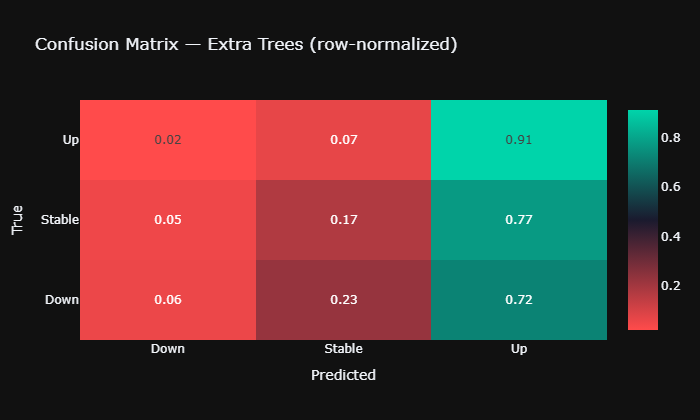

In [15]:
# ── Confusion Matrix Heatmap ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_et, normalize='true')
fig = go.Figure(go.Heatmap(
    z=cm, x=['Down','Stable','Up'], y=['Down','Stable','Up'],
    colorscale=[[0.0, COLORS['down']], [0.5,'#1a1a2e'], [1.0, COLORS['up']]],
    text=np.round(cm,2), texttemplate='%{text}', showscale=True,
))
fig.update_layout(
    title='Confusion Matrix — Extra Trees (row-normalized)',
    xaxis_title='Predicted', yaxis_title='True',
    template=TMPL, height=420,
)
img_path = f'{OUTPUT_DIR}/confusion_matrix.png'
try:
    fig.write_image(img_path, width=700, height=420)
    display(Image(img_path))
except Exception:
    fig.show()

In [16]:
# ── Feature Importance ────────────────────────────────────────────────────────
n_eng = len(eng_cols)
n_pca = X_pca.shape[1]
feat_names = [f'PC{i+1}' for i in range(n_pca)] + eng_cols
importances = et.feature_importances_
top_n = 15
idx = np.argsort(importances)[::-1][:top_n]

fig = go.Figure(go.Bar(
    x=[feat_names[i] for i in idx[::-1]],
    y=importances[idx[::-1]],
    orientation='v', marker_color=COLORS['primary'],
))
fig.update_layout(title=f'Top {top_n} Feature Importances — Extra Trees',
                  template=TMPL, height=380,
                  xaxis_title='Feature', yaxis_title='Importance')
fig.show()

---
## 8. RL Execution Agent

**MDP formulation:**
- **State:** LOB features + inventory + classifier signal probabilities  
- **Actions:** {Buy, Sell, PostBid, PostAsk, Cancel, Hold}  
- **Reward:** $r_t = \Delta\text{PnL} - \lambda|\text{inventory}| - \mu\mathbb{1}[\text{adverse fill}]$

Policy: softmax over linear policy weights (PPO-style update simplified for demonstration)

In [24]:
@dataclass
class RLExecutionAgent:
    """Lightweight PPO-style RL agent for LOB-aware order execution."""
    n_state: int = 15
    n_actions: int = 6
    gamma: float = 0.99
    inv_penalty: float = 0.01
    rng: np.random.Generator = field(
        default_factory=lambda: np.random.default_rng(RANDOM_SEED)
    )

    def __post_init__(self):
        scale = np.sqrt(2.0 / (self.n_state + self.n_actions))
        self.W = self.rng.uniform(-scale, scale, (self.n_state, self.n_actions))

    def _softmax(self, x):
        e = np.exp(x - x.max())
        return e / e.sum()

    def act(self, state: np.ndarray) -> int:
        return int(self.rng.choice(self.n_actions, p=self._softmax(state @ self.W)))

    def reward(self, dpnl: float, inv: float, adverse: bool) -> float:
        return dpnl - self.inv_penalty * abs(inv) - (0.05 if adverse else 0.0)

    def run_episode(self, X_feat: np.ndarray, probs: np.ndarray, n=200) -> dict:
        inv, rewards, action_counts = 0.0, [], np.zeros(self.n_actions, int)
        for t in range(min(n, len(X_feat))):
            # --- REMOVE THESE LINES ---
            # feat = X_feat[t][:self.n_state - 4]
            # state = np.concatenate([feat, [inv/1000.0], probs[t]])[:self.n_state]

            # --- REPLACE WITH THIS ---
            feat = X_feat[t][:self.n_state - 1 - probs.shape[1]]
            raw_state = np.concatenate([feat, [inv / 1000.0], probs[t]])

            # Create the zeroed state and fill it
            state = np.zeros(self.n_state)
            state[:len(raw_state)] = raw_state[:self.n_state]

            # Now 'state' exists and is exactly size 15!
            a = self.act(state)
            action_counts[a] += 1
            # sig = float(probs[t, 2] - probs[t, 0])
            sig = float(probs[t, 1] - probs[t, 0])
            dpnl = sig * self.rng.normal(0.5, 0.3)
            inv += (1 if a == 0 else -1 if a == 1 else 0)
            adv = (a == 0 and sig < -0.2) or (a == 1 and sig > 0.2)
            rewards.append(self.reward(dpnl, inv, adv))
        r = np.array(rewards)
        sharpe = r.mean() / (r.std() + 1e-8) * np.sqrt(252 * n)
        return {'rewards': r, 'cumulative': np.cumsum(r),
                'sharpe': sharpe, 'trades': int(action_counts[:2].sum()),
                'action_counts': action_counts}


agent = RLExecutionAgent()
et_probs = et.predict_proba(X_valid)
episode = agent.run_episode(X_valid, et_probs, n=300)
print(f'RL Episode — Sharpe: {episode["sharpe"]:.4f}, '
      f'Trades: {episode["trades"]}, '
      f'Total Reward: {episode["rewards"].sum():.4f}')

RL Episode — Sharpe: -569.5885, Trades: 119, Total Reward: -133.6380


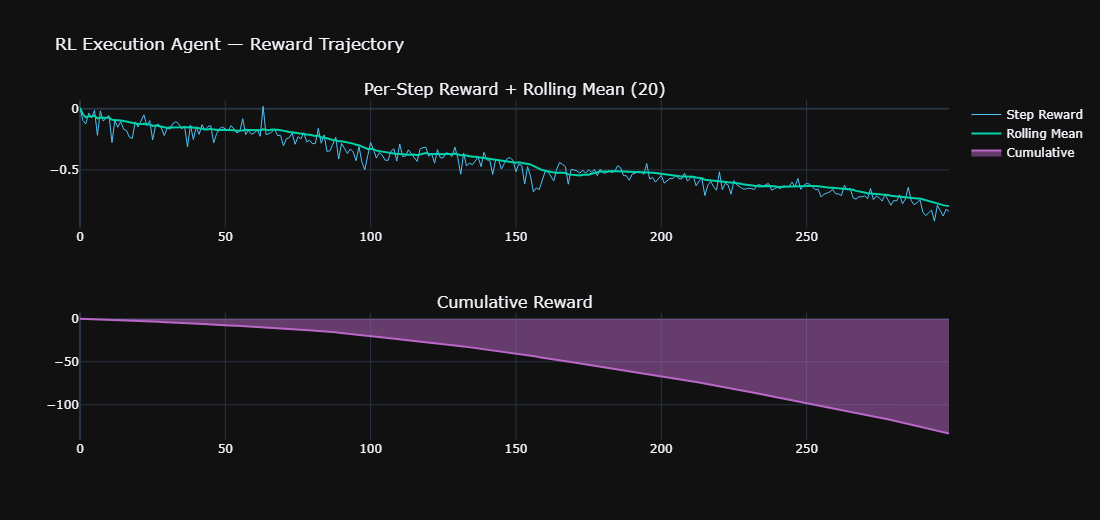

In [25]:
# ── RL reward visualization ───────────────────────────────────────────────────
r = episode['rewards']
rolling = pd.Series(r).rolling(20, min_periods=1).mean().values

fig = make_subplots(rows=2, cols=1,
    subplot_titles=['Per-Step Reward + Rolling Mean (20)',
                    'Cumulative Reward'])
fig.add_trace(go.Scatter(y=r, name='Step Reward',
    line=dict(color=COLORS['primary'], width=1)), row=1, col=1)
fig.add_trace(go.Scatter(y=rolling, name='Rolling Mean',
    line=dict(color=COLORS['up'], width=2)), row=1, col=1)
fig.add_trace(go.Scatter(y=episode['cumulative'], name='Cumulative',
    fill='tozeroy', line=dict(color=COLORS['secondary'], width=2)), row=2, col=1)
fig.update_layout(title='RL Execution Agent — Reward Trajectory',
                  template=TMPL, height=520)
img_path = f'{OUTPUT_DIR}/rl_rewards.png'
try:
    fig.write_image(img_path, width=1100, height=520)
    display(Image(img_path))
except Exception:
    fig.show()

# Action distribution pie
action_labels = ['Buy','Sell','PostBid','PostAsk','Cancel','Hold']
fig2 = go.Figure(go.Pie(
    labels=action_labels, values=episode['action_counts'],
    hole=0.4, marker_colors=[COLORS['up'],COLORS['down'],
    COLORS['primary'],COLORS['secondary'],COLORS['stable'],'#888'],
))
fig2.update_layout(title='RL Action Distribution', template=TMPL, height=350)
fig2.show()

---
## 9. Performance Dashboard

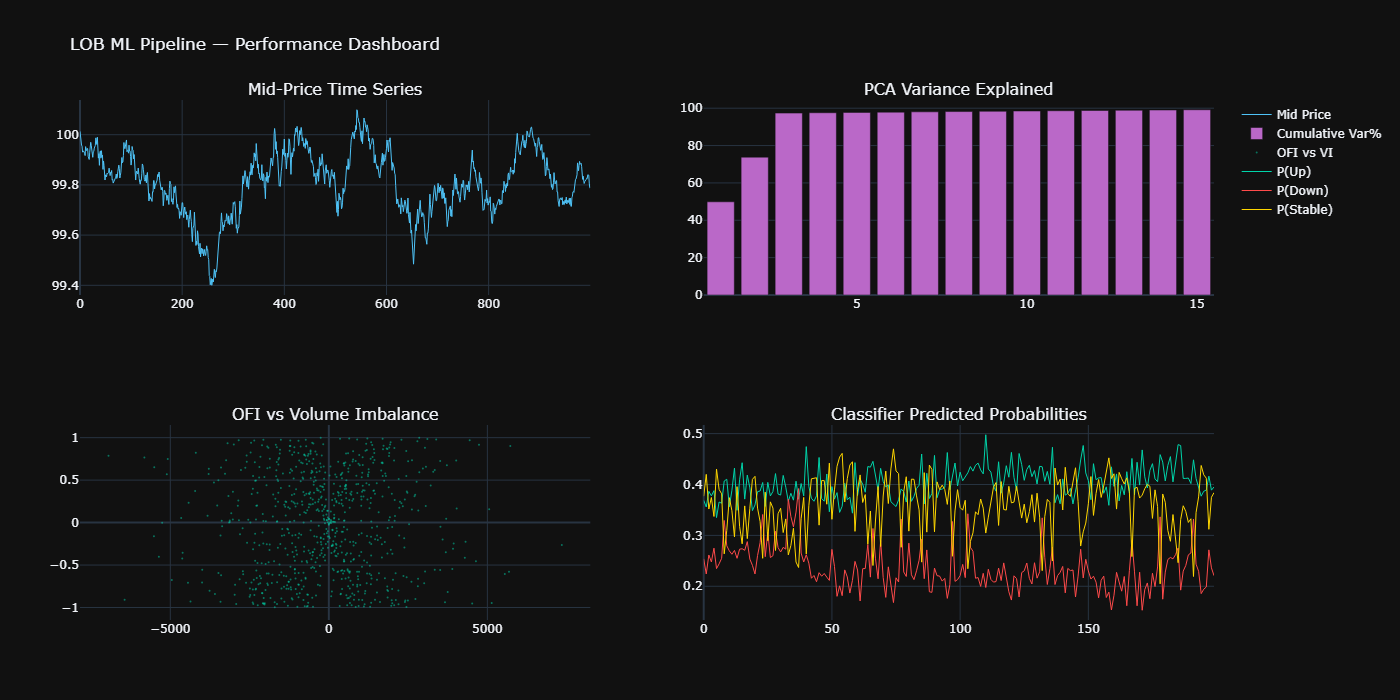


  LOB ML Notebook Complete
  Extra Trees macro-F1 : 0.2865
  LightGBM  macro-F1  : 0.2878
  RL Episode Sharpe    : -569.5885
  PCA components (90%) : 3
  AE latent dim        : 8


In [26]:
# ── Summary dashboard ─────────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Mid-Price Time Series',
        'PCA Variance Explained',
        'OFI vs Volume Imbalance',
        'Classifier Predicted Probabilities',
    ]
)

# Mid price
fig.add_trace(go.Scatter(y=mid_prices[:1000], name='Mid Price',
    line=dict(color=COLORS['primary'], width=1)), row=1, col=1)

# PCA variance
evr = pca_full.explained_variance_ratio_
fig.add_trace(go.Bar(x=list(range(1, 16)), y=np.cumsum(evr[:15])*100,
    name='Cumulative Var%', marker_color=COLORS['secondary']), row=1, col=2)

# OFI vs VI scatter
df_plot = features_df.iloc[:800]
fig.add_trace(go.Scatter(
    x=df_plot['ofi'], y=df_plot['volume_imbalance'],
    mode='markers', name='OFI vs VI',
    marker=dict(color=COLORS['up'], size=2, opacity=0.5),
), row=2, col=1)

# Classifier probs
probs_test = et.predict_proba(X_test[:200])
fig.add_trace(go.Scatter(y=probs_test[:,2], name='P(Up)',
    line=dict(color=COLORS['up'], width=1)), row=2, col=2)
fig.add_trace(go.Scatter(y=probs_test[:,0], name='P(Down)',
    line=dict(color=COLORS['down'], width=1)), row=2, col=2)
fig.add_trace(go.Scatter(y=probs_test[:,1], name='P(Stable)',
    line=dict(color=COLORS['stable'], width=1)), row=2, col=2)

fig.update_layout(
    title='LOB ML Pipeline — Performance Dashboard',
    template=TMPL, height=700, showlegend=True,
)
img_path = f'{OUTPUT_DIR}/dashboard.png'
try:
    fig.write_image(img_path, width=1400, height=700)
    display(Image(img_path))
except Exception:
    fig.show()

print('\n' + '='*55)
print('  LOB ML Notebook Complete')
print(f'  Extra Trees macro-F1 : {f1_et:.4f}')
if HAS_LGB:
    print(f'  LightGBM  macro-F1  : {f1_lgb:.4f}')
print(f'  RL Episode Sharpe    : {episode["sharpe"]:.4f}')
print(f'  PCA components (90%) : {k_opt}')
print(f'  AE latent dim        : {LATENT_DIM}')
print('='*55)